# Uncertainty Features

**Docker image**: `ml4t`

This notebook demonstrates Bayesian and frequentist approaches to extracting
**uncertainty features** — posterior distributions and prediction intervals
become ML inputs, not just diagnostics.

**Learning Objectives**:
- Understand the uncertainty-as-feature principle
- Implement a walk-forward stochastic volatility (SV) model with filtered posteriors
- Extract `vol_posterior_std`, `vol_ci_width`, `vol_of_vol`, and `vol_persistence`
- Compute ARIMA forecast uncertainty on log-volatility with proper back-transform

**Book Reference**: Chapter 9, Section 9.4 (Uncertainty Features)

**Prerequisites**: `08_garch_volatility` for frequentist volatility modeling
(GARCH provides point estimates; this notebook adds uncertainty quantification).
`09_har_rough_volatility` for realized volatility estimators.

In [1]:
"""Uncertainty Features — walk-forward SV posteriors and ARIMA forecast intervals."""

from datetime import datetime

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pymc as pm
from IPython.display import display
from ml4t.diagnostic.evaluation.autocorrelation import analyze_autocorrelation
from ml4t.diagnostic.evaluation.stationarity import analyze_stationarity
from ml4t.engineer.features.volatility import garman_klass_volatility
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

from data import load_etfs
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides for CI
N_DRAWS = 1000
N_TUNE = 2000
N_CHAINS = 2
REFIT_INTERVAL = 63  # Quarterly (~252/4 trading days)
ARIMA_WINDOW = 252
TRAIN_DAYS = 252
SEED = 42

In [3]:
set_global_seeds(SEED)

## Load Data

In [4]:
etfs = load_etfs(symbols=["SPY"])
sp500 = etfs.select(["timestamp", "open", "high", "low", "close"]).sort("timestamp")

start_date = datetime(2015, 1, 1)
end_date = datetime(2024, 12, 31)

sp500 = sp500.filter((pl.col("timestamp") >= start_date) & (pl.col("timestamp") <= end_date))

sp500 = sp500.with_columns(
    returns=pl.col("close").pct_change() * 100,
).drop_nulls()

returns = sp500.to_pandas().set_index("timestamp")["returns"]

print(f"Returns: {len(returns)} observations")
print(f"Date range: {returns.index.min()} to {returns.index.max()}")
print(f"Sample mean: {returns.mean():.4f}%, Sample std: {returns.std():.4f}%")

Returns: 2515 observations
Date range: 2015-01-05 00:00:00 to 2024-12-31 00:00:00
Sample mean: 0.0548%, Sample std: 1.1099%


## Garman-Klass Realized Volatility

ARIMA forecast uncertainty requires a volatility target series. We use the
Garman-Klass estimator (Garman and Klass, 1980) rather than close-to-close
rolling standard deviation. GK incorporates open, high, low, and close prices,
producing a more efficient estimator — see `09_har_rough_volatility` for the
full comparison of range-based estimators.

In [5]:
sp500_gk = sp500.with_columns(
    rv_gk_21=garman_klass_volatility("open", "high", "low", "close", period=21),
).drop_nulls(subset=["rv_gk_21"])

rv_gk = sp500_gk.select(["timestamp", "rv_gk_21"]).to_pandas().set_index("timestamp")["rv_gk_21"]

print(f"Garman-Klass RV (21-day): {len(rv_gk)} observations")
print(f"Mean: {rv_gk.mean():.4f}, Std: {rv_gk.std():.4f}")

Garman-Klass RV (21-day): 2495 observations
Mean: 0.1189, Std: 0.0687


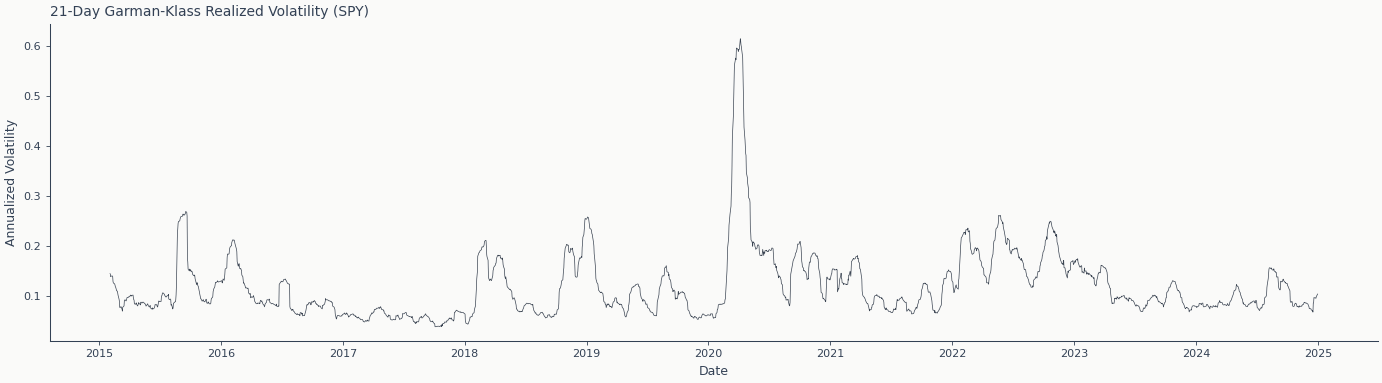

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rv_gk.index, rv_gk.values, linewidth=0.5, alpha=0.8)
ax.set_title("21-Day Garman-Klass Realized Volatility (SPY)")
ax.set_ylabel("Annualized Volatility")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

## The Uncertainty-as-Feature Principle

Any point estimate becomes a distributional feature under Bayesian inference.
A brief example: the Sharpe ratio. The frequentist estimate is a single number;
the Bayesian posterior reveals how uncertain that number is. The same principle
applies to volatility, hedge ratios, and any model parameter — the posterior
width is itself a feature. Chapter 17 develops Bayesian Sharpe estimation fully;
here we apply the principle to volatility and forecasts.

In [7]:
freq_sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
print(f"Frequentist Sharpe (annualized): {freq_sharpe:.3f}")
print("A single number with no uncertainty quantification.")
print("The Bayesian version (Chapter 17) produces a full posterior distribution,")
print("yielding credible intervals and probability statements like P(SR > 0).")

Frequentist Sharpe (annualized): 0.784
A single number with no uncertainty quantification.
The Bayesian version (Chapter 17) produces a full posterior distribution,
yielding credible intervals and probability statements like P(SR > 0).


## Stochastic Volatility Model — Walk-Forward

The canonical SV model specifies an AR(1) process in log-volatility:

$$\log(\sigma_t) = \mu_h + \phi \cdot (\log(\sigma_{t-1}) - \mu_h) + \sigma_\eta \cdot \eta_t$$

We implement this using `pm.AR` with the centered parameterization:
$\tilde{h}_t = \phi \cdot \tilde{h}_{t-1} + \sigma_\eta \cdot \eta_t$
where $\tilde{h}_t = h_t - \mu_h$. The observation model uses Student-t
rather than Gaussian to handle fat tails in financial returns.

### Walk-Forward Protocol

To maintain point-in-time integrity, we refit the SV model at quarterly
boundaries on a trailing training window. At each refit, we extract the
**filtered final state** — the posterior at the last time step, conditioned
only on data up to that point. Between refits, features carry forward the
most recent posterior state. This mirrors the GARCH walk-forward in
`08_garch_volatility` but with quarterly cadence due to MCMC cost.

### SV Model Specification

Define the model as a function for reuse across walk-forward folds.

In [8]:
def fit_sv_model(returns_array, n_draws, n_tune, n_chains):
    """Fit AR(1) stochastic volatility with Student-t observations.

    Returns the MCMC trace (InferenceData object).
    """
    with pm.Model() as sv_model:
        mu_h = pm.Normal("mu_h", mu=0, sigma=5)
        phi = pm.Uniform("phi", lower=0, upper=1)
        sigma_eta = pm.Exponential("sigma_eta", lam=2)
        nu = pm.Deterministic("nu", pm.Gamma("nu_minus2", alpha=2, beta=0.1) + 2)

        h_centered = pm.AR(
            "h_centered",
            rho=[phi],
            sigma=sigma_eta,
            init_dist=pm.Normal.dist(0, 1),
            shape=len(returns_array),
        )
        h = pm.Deterministic("h", h_centered + mu_h)
        volatility = pm.Deterministic("volatility", pm.math.exp(h / 2))

        pm.StudentT("obs", nu=nu, mu=0, sigma=volatility, observed=returns_array)

    with sv_model:
        trace = pm.sample(
            n_draws,
            tune=n_tune,
            chains=n_chains,
            cores=1,
            progressbar=False,
            random_seed=SEED,
            target_accept=0.99,
        )
    return trace

### Walk-Forward Execution

Refit every `REFIT_INTERVAL` trading days (~quarterly). Each refit trains
on the preceding `TRAIN_DAYS` observations. Between refits, we carry forward
the filtered posterior from the training window's final state.

In [9]:
forecast_start = len(returns) - TRAIN_DAYS
refit_points = list(range(forecast_start, len(returns), REFIT_INTERVAL))
n_refits = len(refit_points)

print(f"Walk-forward: {n_refits} refits, interval={REFIT_INTERVAL} days")
print(f"Training window: {TRAIN_DAYS} days, forecast horizon: {len(returns) - forecast_start} days")

sv_features_list = []
last_trace = None

Walk-forward: 4 refits, interval=63 days
Training window: 252 days, forecast horizon: 252 days


In [10]:
for refit_idx, t in enumerate(refit_points):
    train_start = max(0, t - TRAIN_DAYS)
    train_data = returns.iloc[train_start:t].values

    carry_end = min(t + REFIT_INTERVAL, len(returns))
    carry_dates = returns.index[t:carry_end]

    print(
        f"  Refit {refit_idx + 1}/{n_refits}: train [{train_start}:{t}] ({len(train_data)} obs), "
        f"carry [{t}:{carry_end}] ({len(carry_dates)} days)"
    )

    trace = fit_sv_model(train_data, N_DRAWS, N_TUNE, N_CHAINS)
    last_trace = trace

    # Extract FILTERED final state — posterior at the last training time step
    vol_final = trace.posterior["volatility"].values[:, :, -1].flatten()
    phi_post = trace.posterior["phi"].values.flatten()
    sigma_eta_post = trace.posterior["sigma_eta"].values.flatten()
    nu_post = trace.posterior["nu"].values.flatten()

    features = {
        "vol_posterior_mean": vol_final.mean(),
        "vol_posterior_std": vol_final.std(),
        "vol_ci_width": np.percentile(vol_final, 97.5) - np.percentile(vol_final, 2.5),
        "vol_of_vol": sigma_eta_post.mean(),
        "vol_persistence": phi_post.mean(),
    }

    # Carry forward to each day until next refit
    for dt in carry_dates:
        row = {"timestamp": dt, **features}
        sv_features_list.append(row)

    # Per-refit diagnostics
    n_div = int(trace.sample_stats["diverging"].values.sum())
    print(
        f"    phi={phi_post.mean():.3f}, sigma_eta={sigma_eta_post.mean():.3f}, "
        f"nu={nu_post.mean():.1f}, divergences={n_div}"
    )

sv_features_df = pd.DataFrame(sv_features_list).set_index("timestamp")
print(f"\nSV features: {len(sv_features_df)} daily observations ({n_refits} refit points)")

  Refit 1/4: train [2011:2263] (252 obs), carry [2263:2326] (63 days)


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu_h, phi, sigma_eta, nu_minus2, h_centered]


Sampling 2 chains for 2_000 tune and 1_000 draw iterations (4_000 + 2_000 draws total) took 51 seconds.


...

Sampling 2 chains for 2_000 tune and 1_000 draw iterations (4_000 + 2_000 draws total) took 39 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


    phi=0.756, sigma_eta=0.330, nu=25.2, divergences=0

SV features: 252 daily observations (4 refit points)


### MCMC Diagnostics

Beyond divergence counts, we check $\hat{R}$ (convergence across chains) and
effective sample size (ESS). $\hat{R} > 1.05$ or ESS below 100 indicate the
sampler has not explored the posterior adequately.

SV models are notoriously difficult for NUTS because the latent AR(1) path
creates a funnel geometry between $\phi$, $\sigma_\eta$, and the 252 latent
states. Expect lower ESS for these parameters than for $\mu_h$ and $\nu$,
which are better identified. This is a genuine operational consideration:
production SV implementations often use particle MCMC or sequential Monte
Carlo rather than NUTS to handle this geometry.

In [11]:
# Diagnostics from the last refit
diag_vars = ["phi", "sigma_eta", "mu_h", "nu"]
summary = az.summary(last_trace, var_names=diag_vars)
display(summary)

n_divergences = int(last_trace.sample_stats["diverging"].values.sum())
print(f"\nDivergences: {n_divergences}")

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
phi,0.756,0.224,0.237,0.990,0.052,0.043,21.0,36.0,1.04
sigma_eta,0.330,0.155,0.099,0.641,0.037,0.034,17.0,23.0,1.10
mu_h,-0.712,0.206,-1.100,-0.341,0.011,0.012,400.0,402.0,1.00
nu,25.245,14.195,6.265,51.237,0.281,0.426,2504.0,1506.0,1.00



Divergences: 0


### Walk-Forward SV Features

The plot shows piecewise-constant features that update at each quarterly
refit. This honestly reflects the production protocol: features carry the
last filtered state forward between re-estimations.

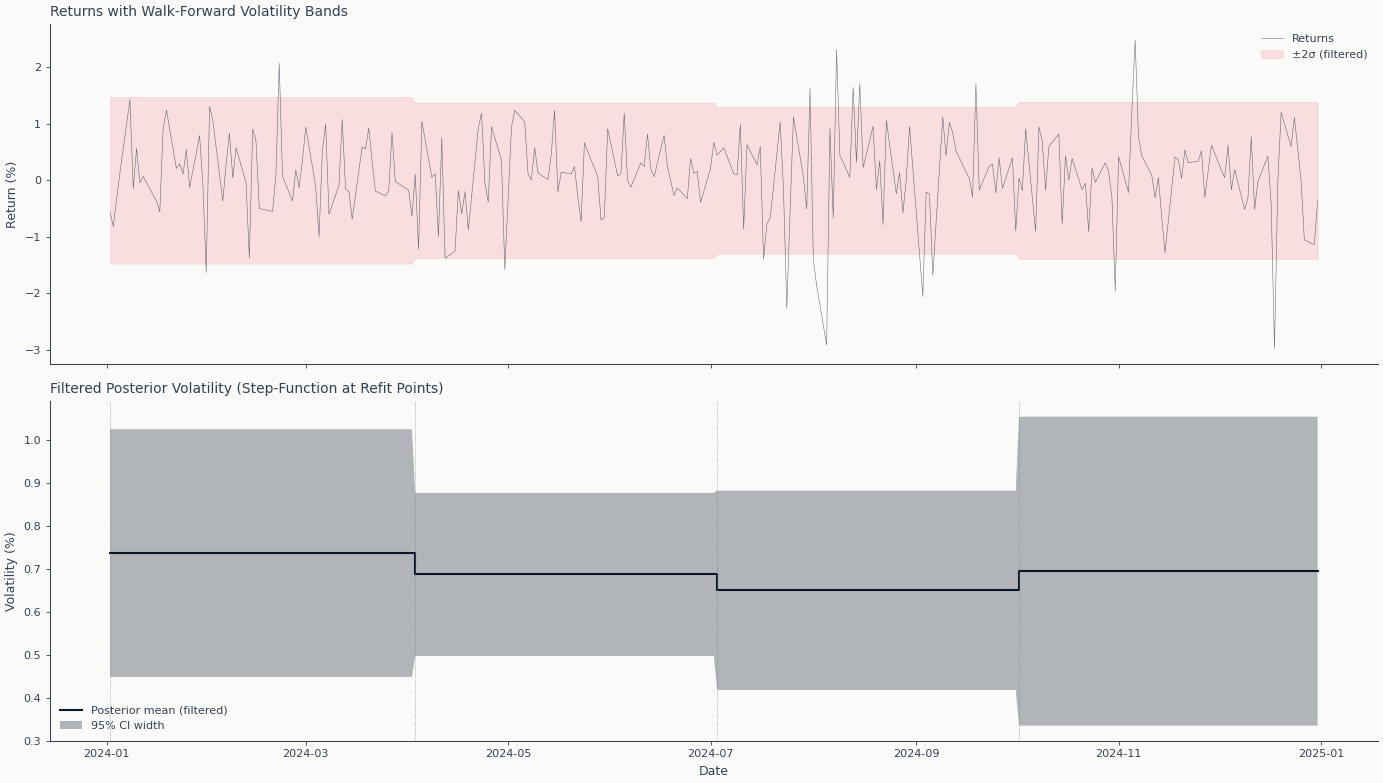

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
wf_dates = sv_features_df.index
ax.plot(
    returns.loc[wf_dates].index,
    returns.loc[wf_dates].values,
    linewidth=0.4,
    alpha=0.6,
    label="Returns",
)
ax.fill_between(
    wf_dates,
    -2 * sv_features_df["vol_posterior_mean"],
    2 * sv_features_df["vol_posterior_mean"],
    alpha=0.15,
    color=COLORS["negative"],
    label="±2σ (filtered)",
)
ax.set_title("Returns with Walk-Forward Volatility Bands")
ax.set_ylabel("Return (%)")
ax.legend()

ax = axes[1]
ax.plot(
    wf_dates,
    sv_features_df["vol_posterior_mean"],
    linewidth=1.5,
    label="Posterior mean (filtered)",
    drawstyle="steps-post",
)
ax.fill_between(
    wf_dates,
    sv_features_df["vol_posterior_mean"] - sv_features_df["vol_ci_width"] / 2,
    sv_features_df["vol_posterior_mean"] + sv_features_df["vol_ci_width"] / 2,
    alpha=0.3,
    label="95% CI width",
)
for rp in refit_points:
    if rp < len(returns):
        ax.axvline(returns.index[rp], color="gray", linestyle=":", linewidth=0.5)
ax.set_title("Filtered Posterior Volatility (Step-Function at Refit Points)")
ax.set_ylabel("Volatility (%)")
ax.set_xlabel("Date")
ax.legend()

plt.tight_layout()
plt.show()

**Interpretation**: The step-function updates show how SV features evolve at
quarterly refits. Between refits, features are constant — reflecting the
production reality that MCMC is too expensive to run daily. The CI width
varies across refits, widening during uncertain periods.

### Parameter Posteriors (Last Refit)

=== SV Parameter Posteriors (Last Refit) ===
phi (persistence):     mean=0.756, std=0.224
sigma_eta (vol-of-vol): mean=0.330, std=0.155
mu_h (mean log-vol):   mean=-0.712, std=0.206
nu (Student-t df):     mean=25.2, std=14.2


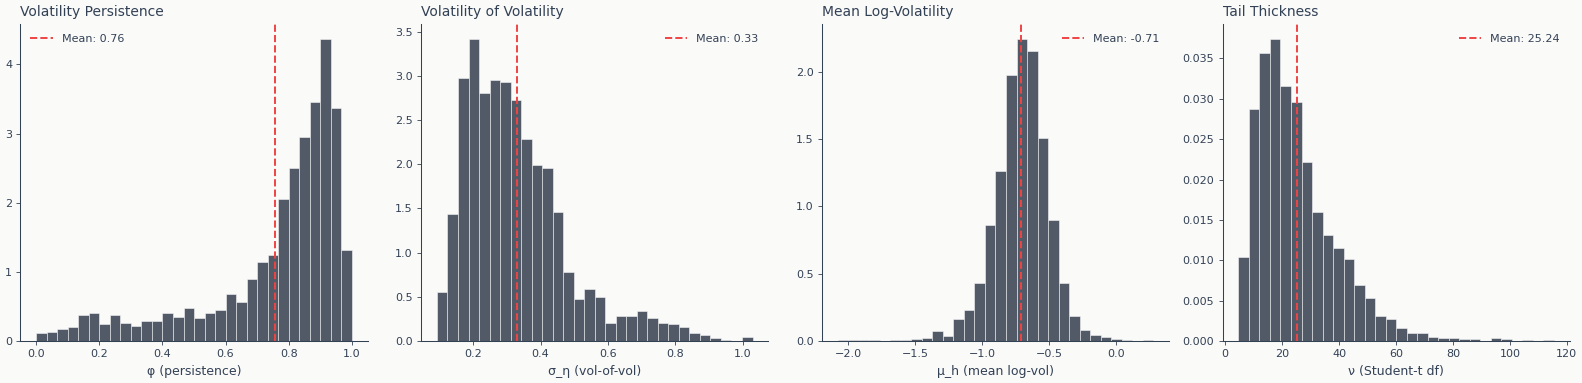

In [13]:
phi_samples = last_trace.posterior["phi"].values.flatten()
sigma_eta_samples = last_trace.posterior["sigma_eta"].values.flatten()
mu_h_samples = last_trace.posterior["mu_h"].values.flatten()
nu_samples = last_trace.posterior["nu"].values.flatten()

print("=== SV Parameter Posteriors (Last Refit) ===")
print(f"phi (persistence):     mean={phi_samples.mean():.3f}, std={phi_samples.std():.3f}")
print(
    f"sigma_eta (vol-of-vol): mean={sigma_eta_samples.mean():.3f}, std={sigma_eta_samples.std():.3f}"
)
print(f"mu_h (mean log-vol):   mean={mu_h_samples.mean():.3f}, std={mu_h_samples.std():.3f}")
print(f"nu (Student-t df):     mean={nu_samples.mean():.1f}, std={nu_samples.std():.1f}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, samples, label, title in zip(
    axes,
    [phi_samples, sigma_eta_samples, mu_h_samples, nu_samples],
    ["φ (persistence)", "σ_η (vol-of-vol)", "μ_h (mean log-vol)", "ν (Student-t df)"],
    ["Volatility Persistence", "Volatility of Volatility", "Mean Log-Volatility", "Tail Thickness"],
    strict=False,
):
    ax.hist(samples, bins=30, density=True, alpha=0.7, edgecolor="white")
    ax.axvline(
        samples.mean(),
        color=COLORS["negative"],
        linestyle="--",
        label=f"Mean: {samples.mean():.2f}",
    )
    ax.set_xlabel(label)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Interpretation**: The $\phi$ posterior captures volatility persistence — values
near 1 mean shocks decay slowly (clustering), lower values indicate faster
mean-reversion. The $\nu$ posterior indicates tail thickness: values near 4–6
confirm that Student-t is substantially better than Gaussian ($\nu \to \infty$);
values above 30 suggest Gaussian is adequate. Both $\sigma_\eta$ (vol-of-vol)
and $\phi$ are re-estimated quarterly and serve as slowly varying features.

### Scalability

Full MCMC-based SV is practical for small universes (tens of assets). For
large panels (1000+ assets), pragmatic alternatives include:
- **Sector aggregates**: Run SV on sector ETFs, broadcast uncertainty features
- **Variational inference**: `pm.fit()` gives faster but less accurate posteriors
- **GARCH baseline with SV overlay**: Reserve SV for portfolio-level risk

See the chapter text (§9.4) for universe-size guidance.

## ARIMA Forecast Uncertainty on Log-Volatility

ARIMA produces prediction intervals alongside point forecasts. We apply it
to **log-volatility** rather than raw volatility for two reasons:

1. Log-transform ensures forecasts stay positive (volatility cannot be negative)
2. ARIMA residuals on log-vol are more Gaussian, improving interval coverage

The back-transform uses the log-normal property: $\exp(\mu_f)$ gives the
**median** forecast on the original scale (not the mean, which is
$\exp(\mu_f + \sigma_f^2/2)$). The prediction interval is
$[\exp(\mu_f - z \cdot \sigma_f),\; \exp(\mu_f + z \cdot \sigma_f)]$.
Both the median and the interval are exact, not approximations.

### Pre-ARIMA Diagnostics

Before fitting, examine stationarity and autocorrelation structure. ADF and
Phillips-Perron reject a unit root while KPSS disagrees (consensus: likely
stationary, 0.67 agreement), so the differencing order is genuinely ambiguous.
We let AutoARIMA's AIC search settle it below — it selects a first difference.

In [14]:
log_rv = np.log(rv_gk.clip(lower=1e-8))

stat_check = analyze_stationarity(log_rv.dropna().values)
acf_analysis = analyze_autocorrelation(log_rv.dropna().values)

print("=== Pre-ARIMA Diagnostics (log Garman-Klass RV) ===")
print(f"Stationarity: {stat_check.consensus} (agreement: {stat_check.agreement_score:.2f})")
print(f"Suggested ARIMA order: {acf_analysis.suggested_arima_order}")

2026-07-13 23:56:08,323 - ml4t.diagnostic.evaluation.stationarity.analysis - INFO - Running comprehensive stationarity analysis (n_obs=2495 tests=['adf', 'kpss', 'pp'] alpha=0.05)


2026-07-13 23:56:08,323 - ml4t.diagnostic.evaluation.stationarity.augmented_dickey_fuller - INFO - Running ADF test (n_obs=2495 maxlag=None regression=c autolag=AIC)


2026-07-13 23:56:08,352 - ml4t.diagnostic.evaluation.stationarity.augmented_dickey_fuller - INFO - ADF test completed (statistic=-3.9179267205663377 p_value=0.001906806644747079 lags_used=24 n_obs=2470 stationary=True)


2026-07-13 23:56:08,352 - ml4t.diagnostic.evaluation.stationarity.analysis - INFO - ADF test completed (stationary=True)


2026-07-13 23:56:08,353 - ml4t.diagnostic.evaluation.stationarity.kpss_test - INFO - Running KPSS test (n_obs=2495 regression=c nlags=auto)


...

2026-07-13 23:56:08,360 - ml4t.diagnostic.evaluation.autocorrelation - INFO - Starting autocorrelation analysis


2026-07-13 23:56:08,362 - ml4t.diagnostic.evaluation.autocorrelation - INFO - ACF computed (n_obs=2495 nlags=33 significant=33)


2026-07-13 23:56:08,369 - ml4t.diagnostic.evaluation.autocorrelation - INFO - PACF computed (n_obs=2495 nlags=33 significant=14)


2026-07-13 23:56:08,370 - ml4t.diagnostic.evaluation.autocorrelation - INFO - Autocorrelation analysis completed (arima_order=(5, 0, 33) white_noise=False)


=== Pre-ARIMA Diagnostics (log Garman-Klass RV) ===
Stationarity: likely_stationary (agreement: 0.67)
Suggested ARIMA order: (5, 0, 33)


### Order Selection and Rolling Forecast via Nixtla

We use Nixtla's `AutoARIMA` (compiled C, AIC-based order selection) on the
first training window to choose (p, d, q), then roll forward with that fixed
order using Nixtla's `ARIMA` for speed. The model operates on
$\log(\text{RV}_{GK})$; we back-transform to the original scale afterward.

$\exp(\hat{\mu}_f)$ gives the **median** forecast on the original scale
(not the mean $\exp(\hat{\mu}_f + \hat{\sigma}_f^2/2)$), which is more
robust for position sizing.

In [15]:
from statsforecast.models import ARIMA as NixtlaARIMA

log_rv_clean = log_rv.dropna()

# Step 1: AutoARIMA order selection on first training window
first_window_df = pd.DataFrame(
    {
        "unique_id": "SPY",
        "ds": log_rv_clean.index[:ARIMA_WINDOW],
        "y": log_rv_clean.values[:ARIMA_WINDOW],
    }
)

sf_auto = StatsForecast(models=[AutoARIMA(season_length=1)], freq="B", n_jobs=1)
sf_auto.fit(first_window_df)
selected_order = sf_auto.fitted_[0, 0].model_["arma"]
p, q, P, Q, s, d, D = selected_order
print(f"AutoARIMA selected: ARIMA({p},{d},{q})")

AutoARIMA selected: ARIMA(1,1,1)


In [16]:
# Step 2: Rolling forecast with fixed order (fast)
n_total = len(log_rv_clean)
n_windows = n_total - ARIMA_WINDOW

arima_input = pd.DataFrame(
    {
        "unique_id": "SPY",
        "ds": log_rv_clean.index,
        "y": log_rv_clean.values,
    }
)

sf = StatsForecast(
    models=[NixtlaARIMA(order=(p, d, q), season_length=1)],
    freq="B",
    n_jobs=1,
)
cv_result = sf.cross_validation(
    df=arima_input,
    h=1,
    step_size=1,
    n_windows=n_windows,
    level=[95],
)

# Back-transform from log scale to original scale
col = "ARIMA"
arima_df = pd.DataFrame(
    {
        "timestamp": cv_result["ds"].values,
        "arima_forecast": np.exp(cv_result[col].values),
        "arima_lo_95": np.exp(cv_result[f"{col}-lo-95"].values),
        "arima_hi_95": np.exp(cv_result[f"{col}-hi-95"].values),
        "actual": np.exp(cv_result["y"].values),
    }
)
arima_df["arima_ci_width"] = arima_df["arima_hi_95"] - arima_df["arima_lo_95"]
arima_df["forecast_uncertainty_ratio"] = arima_df["arima_ci_width"] / arima_df["arima_forecast"]

# Forecast std from the CI width on original scale (robust to negative log-CIs)
arima_df["arima_forecast_std"] = arima_df["arima_ci_width"] / (2 * 1.96)

arima_df = arima_df.set_index("timestamp")

print(f"ARIMA({p},{d},{q}) forecast features: {len(arima_df)} observations")

ARIMA(1,1,1) forecast features: 2243 observations


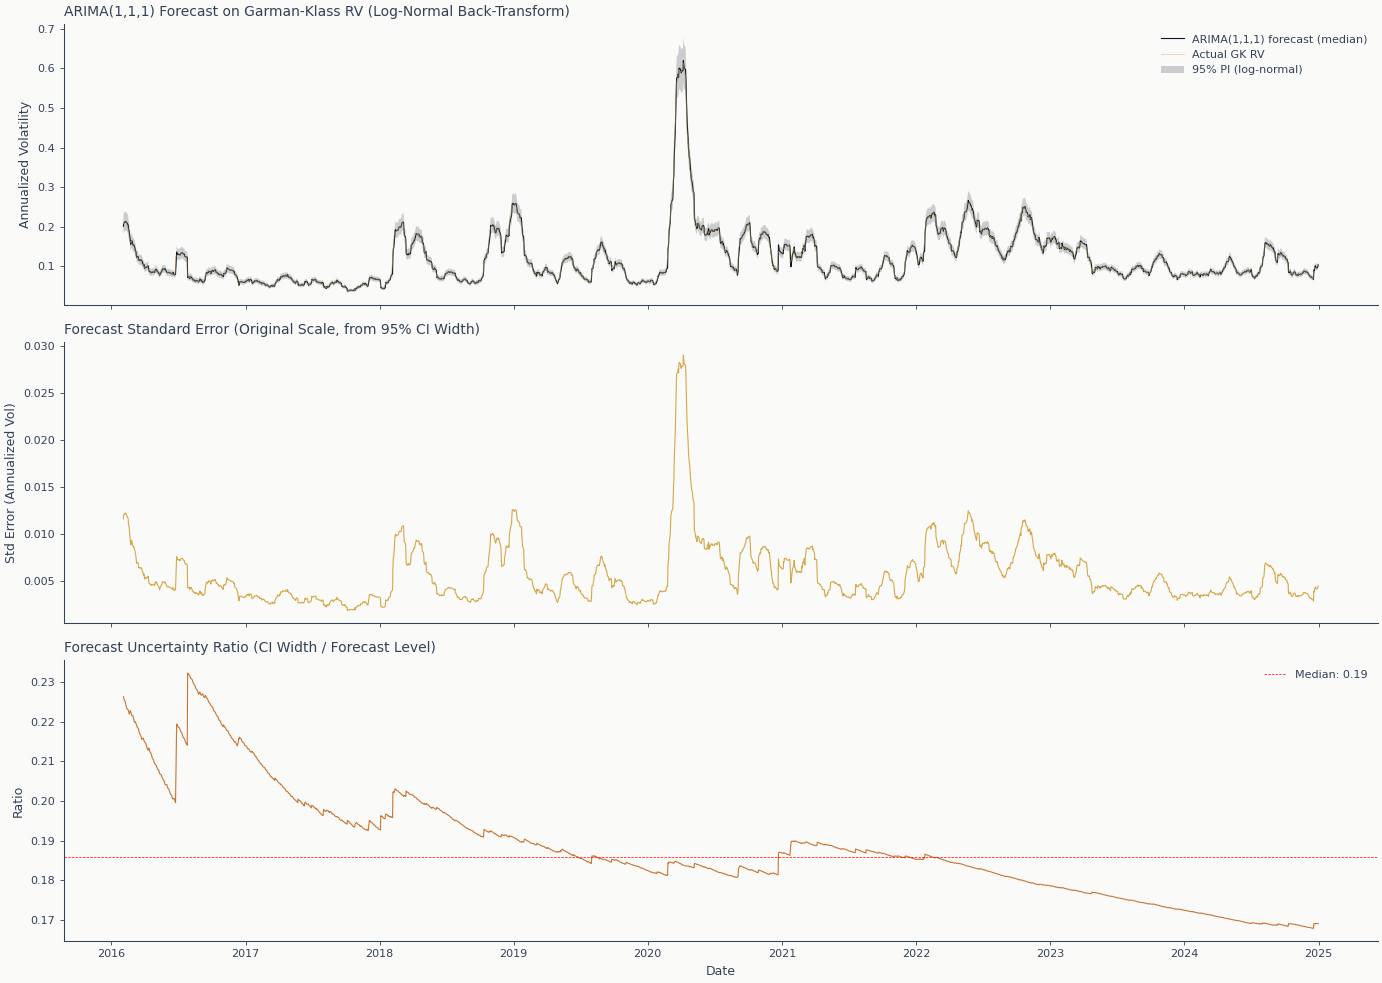

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
ax.plot(
    arima_df.index,
    arima_df["arima_forecast"],
    linewidth=0.8,
    label=f"ARIMA({p},{d},{q}) forecast (median)",
)
ax.plot(
    arima_df.index,
    arima_df["actual"],
    linewidth=0.5,
    alpha=0.6,
    color=COLORS["amber"],
    label="Actual GK RV",
)
ax.fill_between(
    arima_df.index,
    arima_df["arima_lo_95"],
    arima_df["arima_hi_95"],
    alpha=0.2,
    label="95% PI (log-normal)",
)
ax.set_title(f"ARIMA({p},{d},{q}) Forecast on Garman-Klass RV (Log-Normal Back-Transform)")
ax.set_ylabel("Annualized Volatility")
ax.legend()

ax = axes[1]
ax.plot(arima_df.index, arima_df["arima_forecast_std"], linewidth=0.8, color=COLORS["amber"])
ax.set_title("Forecast Standard Error (Original Scale, from 95% CI Width)")
ax.set_ylabel("Std Error (Annualized Vol)")

ax = axes[2]
ax.plot(
    arima_df.index, arima_df["forecast_uncertainty_ratio"], linewidth=0.8, color=COLORS["copper"]
)
ax.axhline(
    arima_df["forecast_uncertainty_ratio"].median(),
    color="red",
    linestyle="--",
    linewidth=0.5,
    label=f"Median: {arima_df['forecast_uncertainty_ratio'].median():.2f}",
)
ax.set_title("Forecast Uncertainty Ratio (CI Width / Forecast Level)")
ax.set_ylabel("Ratio")
ax.set_xlabel("Date")
ax.legend()

plt.tight_layout()
plt.show()

**Interpretation**: The forecast standard error spikes during volatile periods
(COVID, 2022 rate hikes) — precisely when the model is least confident.
The log-normal back-transform produces asymmetric prediction intervals on the
original scale: wider on the upside, reflecting that volatility spikes are
unbounded while the floor is zero. The order was selected by AutoARIMA on
the first window; periodic reselection would guard against structural change.

## Feature Summary

In [18]:
print("SV Uncertainty Features (Walk-Forward):")
display(sv_features_df.describe().round(4))

print("ARIMA Uncertainty Features (AutoARIMA on Log-Vol):")
display(
    arima_df[["arima_forecast_std", "arima_ci_width", "forecast_uncertainty_ratio"]]
    .describe()
    .round(4)
)

SV Uncertainty Features (Walk-Forward):


,vol_posterior_mean,vol_posterior_std,vol_ci_width,vol_of_vol,vol_persistence
count,252.0000,252.0000,252.0000,252.0000,252.0000
mean,0.6925,0.1331,0.5342,0.2531,0.5391
std,0.0308,0.0340,0.1274,0.0521,0.1539
min,0.6506,0.0911,0.3791,0.1975,0.3632
25%,0.6782,0.1089,0.4423,0.2098,0.4139
50%,0.6912,0.1296,0.5197,0.2427,0.5184
75%,0.7055,0.1538,0.6115,0.2860,0.6436
max,0.7371,0.1818,0.7183,0.3296,0.7564


ARIMA Uncertainty Features (AutoARIMA on Log-Vol):


,arima_forecast_std,arima_ci_width,forecast_uncertainty_ratio
count,2243.0000,2243.0000,2243.0000
mean,0.0057,0.0223,0.1884
std,0.0033,0.0131,0.0137
min,0.0019,0.0073,0.1679
25%,0.0035,0.0138,0.1802
50%,0.0046,0.0181,0.1858
75%,0.0070,0.0274,0.1950
max,0.0291,0.1139,0.2323


### Production Notes

The walk-forward protocol implemented above is the correct production pattern:
SV features are re-estimated at periodic boundaries and carried forward between
refits. ARIMA features update daily with negligible cost (refit on a rolling
window and call `get_forecast()`).

For production hardening beyond this notebook:
- **Particle filtering** provides online posterior updates without full MCMC
  re-estimation — useful for daily SV updates between quarterly refits
- AutoARIMA reselects the order at each window automatically; for even
  faster rolling forecasts, fix the order after an initial selection pass

## Save Uncertainty Features

In [19]:
MODEL_DIR = get_case_study_dir("etfs") / "models" / "time_series"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

arima_save_cols = [
    "arima_forecast",
    "arima_forecast_std",
    "arima_ci_width",
    "forecast_uncertainty_ratio",
]
arima_output = pl.from_pandas(arima_df[arima_save_cols].reset_index())
arima_path = MODEL_DIR / "arima_uncertainty.parquet"
arima_output.write_parquet(arima_path)
print(f"Saved ARIMA uncertainty features to {arima_path}")
print(f"  Shape: {arima_output.shape}")

sv_output = pl.from_pandas(sv_features_df.reset_index())
sv_path = MODEL_DIR / "sv_uncertainty.parquet"
sv_output.write_parquet(sv_path)
print(f"Saved SV uncertainty features to {sv_path}")
print(f"  Shape: {sv_output.shape}")

Saved ARIMA uncertainty features to case_studies/etfs/models/time_series/arima_uncertainty.parquet
  Shape: (2243, 5)
Saved SV uncertainty features to case_studies/etfs/models/time_series/sv_uncertainty.parquet
  Shape: (252, 6)


## Key Takeaways

1. **Walk-forward SV preserves point-in-time integrity** — the filtered final
   state from each training window produces features conditioned only on past
   data, unlike full-sample smoothed posteriors
2. **Student-t observation model handles fat tails** — the estimated $\nu$
   posterior confirms whether Gaussian is adequate; values near 4–6 show
   Student-t materially improves the fit
3. **Vol persistence ($\phi$) and vol-of-vol ($\sigma_\eta$)** are complementary:
   $\phi$ near 1 means shocks decay slowly; high $\sigma_\eta$ means the
   volatility process itself is unstable
4. **Log-vol ARIMA ensures positive forecasts** — the log-normal back-transform
   produces exact, asymmetric prediction intervals on the original scale
5. **MCMC diagnostics go beyond divergences** — $\hat{R}$, ESS, and the $\nu$
   posterior all provide information about posterior reliability
6. **Computational cost scales with universe** — full MCMC is practical for
   tens of assets; large panels require variational inference or sector aggregates

**Previous**: `09_har_rough_volatility` for multi-horizon volatility decomposition.
**Next**: `11_hmm_regimes` for regime detection via Hidden Markov Models.